# Churn Dataset: Pooled Top-k Ranking Experiment

This notebook runs a ranking-based LazyFCA experiment on the churn dataset.

Main idea:
- keep the usual baseline thresholds only as a permissive pre-filter,
- for each query object, pool positive and negative classifiers together,
- rank the pooled classifiers by one chosen metric,
- keep only the Top-k classifiers from that pooled list,
- classify using only those Top-k classifiers,
- plot F1 as a function of k.

This differs from the threshold notebook because it does not sweep a metric threshold. Instead, it turns the explanation into a ranked list and truncates it directly.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MPLCONFIGDIR = ROOT / "experiments" / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection
import tqdm.auto as tqdm

PLOTS_DIR = ROOT / "experiments" / "generated_plots" / "taxi_topk_ranking_raw"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

from lazyfca.lazyfca import LazyFCA
from utils.estimate_quality import estimate_quality

In [2]:
import pandas
import sklearn.compose
import sklearn.model_selection
import sklearn.preprocessing

numeric = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'Airport_fee',
    'cbd_congestion_fee'
]

categorical = [
    'VendorID',
    'RatecodeID',
    'store_and_fwd_flag',
    # 'PULocationID',
    # 'DOLocationID',
    'payment_type',
]

target = 'tip_amount'

data = pandas.read_parquet("../datasets/yellow_tripdata_2026-01.parquet")
data = data[~data['passenger_count'].isna()]
data = pandas.concat([
    data[data['tip_amount'] != 0][:5000],
    data[data['tip_amount'] == 0][:5000]
])

y = (data['tip_amount'] != 0).to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    data, y, test_size = 0.1, stratify = y, random_state = 42
)

ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool', sparse_output = False), categorical)
    ]
)
X_train = pandas.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())
X_train

,numeric__passenger_count,numeric__trip_distance,numeric__fare_amount,numeric__extra,numeric__mta_tax,numeric__tolls_amount,numeric__improvement_surcharge,numeric__congestion_surcharge,numeric__Airport_fee,numeric__cbd_congestion_fee,...,categorical__RatecodeID_3.0,categorical__RatecodeID_4.0,categorical__RatecodeID_5.0,categorical__RatecodeID_99.0,categorical__store_and_fwd_flag_N,categorical__store_and_fwd_flag_Y,categorical__payment_type_1,categorical__payment_type_2,categorical__payment_type_3,categorical__payment_type_4
0,1.0,0.90,8.6,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,2.0,1.04,8.6,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,1.60,12.1,4.25,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,3.22,18.4,1.00,0.5,0.0,1.0,2.5,0.0,0.00,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,4.35,24.7,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,1.0,2.83,18.4,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
8996,3.0,1.20,9.3,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
8997,1.0,0.00,21.2,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
8998,1.0,5.41,25.4,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [3]:
import catboost
classifier = catboost.CatBoostClassifier(iterations = 100)
classifier.fit(X_train, y_train)
y_pred = classifier.predict_proba(X_test)
estimate_quality(y_pred, y_test)

Learning rate set to 0.217468
0:	learn: 0.4662080	total: 142ms	remaining: 14s
1:	learn: 0.3857035	total: 145ms	remaining: 7.09s
2:	learn: 0.3525028	total: 148ms	remaining: 4.77s
3:	learn: 0.3362284	total: 151ms	remaining: 3.63s
4:	learn: 0.3272794	total: 154ms	remaining: 2.92s
5:	learn: 0.3205173	total: 157ms	remaining: 2.46s
6:	learn: 0.3162332	total: 159ms	remaining: 2.12s
7:	learn: 0.3127534	total: 162ms	remaining: 1.86s
8:	learn: 0.3110062	total: 164ms	remaining: 1.66s
9:	learn: 0.3091644	total: 166ms	remaining: 1.5s
10:	learn: 0.3086836	total: 168ms	remaining: 1.36s
11:	learn: 0.3072445	total: 170ms	remaining: 1.25s
12:	learn: 0.3062559	total: 172ms	remaining: 1.15s
13:	learn: 0.3054604	total: 174ms	remaining: 1.07s
14:	learn: 0.3050157	total: 177ms	remaining: 1s
15:	learn: 0.3042469	total: 179ms	remaining: 939ms
16:	learn: 0.3040692	total: 180ms	remaining: 880ms
17:	learn: 0.3032883	total: 182ms	remaining: 830ms
18:	learn: 0.3029447	total: 186ms	remaining: 792ms
19:	learn: 0.3026

{'Accuracy': 0.888,
 'Precision': 0.8310580204778157,
 'Recall': 0.974,
 'AUC-ROC': 0.915594,
 'F1-score': 0.8968692449355433,
 'True Positive': 487,
 'True Negative': 401,
 'False Positive': 99,
 'False Negative': 13,
 'True Negative Rate (Specificity)': 0.802,
 'Negative Predictive Value': 0.9685990338164251,
 'False Positive Rate': 0.198,
 'False Discovery Rate': 0.1689419795221843}

## Baseline Threshold Params

`LazyFCA.Params(...)` is the threshold object used by LazyFCA.

Important detail:
- this object reuses the same dataclass as the metrics themselves,
- but when passed into `LazyFCA(...)`, its values are interpreted as lower/upper bounds for filtering classifiers.

Example:
- `supporters_covered=1` means keep only classifiers covering at least 1 supporter,
- `supporter_opposer_ratio=1.0` means keep only classifiers whose supporter/opposer ratio is at least 1.0.

Here we keep the same baseline thresholds as in the original rice notebook. They serve only as a permissive pre-filter before ranking.

In [4]:
baseline_classifier = LazyFCA()
baseline_classifier.fit(X_train, y_train)

In [5]:
# Baseline threshold-only performance for reference.
baseline_y_pred = baseline_classifier.predict(X_test)
baseline_metrics = estimate_quality(baseline_y_pred, y_test)
baseline_metrics

100%|██████████| 1000/1000 [15:42<00:00,  1.06it/s]


{'Accuracy': 0.5,
 'Precision': 0.0,
 'Recall': 0.0,
 'AUC-ROC': 0.5,
 'F1-score': 0.0,
 'True Positive': 0,
 'True Negative': 500,
 'False Positive': 0,
 'False Negative': 500,
 'True Negative Rate (Specificity)': 1.0,
 'Negative Predictive Value': 0.5,
 'False Positive Rate': 0.0,
 'False Discovery Rate': 0}

## Precompute Explanations Once

Efficiency idea:
- explanations are the expensive part,
- threshold sweeps or top-k sweeps should not recompute them,
- we precompute them once using the baseline threshold filter,
- every metric/k experiment reuses those explanations.

In [6]:
explanations = baseline_classifier.explain(X_test)
len(explanations)

100%|██████████| 1000/1000 [17:32<00:00,  1.05s/it]


1000

In [7]:
available_metrics = [
    "supporters_covered",
    "opposers_covered",
    "supporter_opposer_ratio",
    "support",
    "error_rate",
    "precision",
    "lift",
    "wracc",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "interval_tightness",
    "description_volume",
    "simplicity_prior",
    "query_binary_similarity",
    "query_numeric_similarity",
    "query_similarity",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "robustness",
    "delta_stability",
]

available_metrics

['supporters_covered',
 'opposers_covered',
 'supporter_opposer_ratio',
 'support',
 'error_rate',
 'precision',
 'lift',
 'wracc',
 'balanced_precision_proxy',
 'youdens_j',
 'matthews_correlation',
 'information_gain',
 'gini_gain',
 'log_odds_ratio',
 'chi_squared',
 'g_test',
 'interval_tightness',
 'description_volume',
 'simplicity_prior',
 'query_binary_similarity',
 'query_numeric_similarity',
 'query_similarity',
 'query_weighted_precision',
 'query_weighted_wracc',
 'stability',
 'robustness',
 'delta_stability']

## Efficient Pooled Top-k Evaluation

For each explanation and each metric:
1. put positive and negative classifiers in one pooled list,
2. score them by the chosen metric,
3. sort descending,
4. compute cumulative counts of positive and negative classifiers,
5. reuse those cumulative counts for all values of k.

This makes each metric experiment much faster than recomputing `predict()` for every k.

In [8]:
MINIMIZED_METRICS = {"opposers_covered", "error_rate", "description_volume"}

def metric_score(classifier, metric_name):
    value = getattr(classifier.get_metrics(), metric_name)
    return -value if metric_name in MINIMIZED_METRICS else value

def build_metric_cache(explanations, metric_name):
    cache = []
    for explanation in tqdm.tqdm(explanations, desc=f"Caching {metric_name}"):
        pooled = [
            *[(metric_score(clf, metric_name), 1) for clf in explanation.positive_classifiers],
            *[(metric_score(clf, metric_name), 0) for clf in explanation.negative_classifiers],
        ]

        if not pooled:
            cache.append({
                "total": 0,
                "cum_pos": np.array([], dtype=np.int32),
                "cum_neg": np.array([], dtype=np.int32),
            })
            continue

        pooled.sort(key=lambda item: item[0], reverse=True)
        labels = np.array([label for _, label in pooled], dtype=np.int32)
        cum_pos = np.cumsum(labels)
        cum_neg = np.cumsum(1 - labels)

        cache.append({
            "total": len(labels),
            "cum_pos": cum_pos,
            "cum_neg": cum_neg,
        })

    return cache

def predict_from_metric_cache(metric_cache, k, pos_weight=1.0):
    y_pred = np.zeros((len(metric_cache), 2), dtype=np.float64)

    for i, item in enumerate(metric_cache):
        total_available = item["total"]
        if total_available == 0 or k <= 0:
            y_pred[i] = [0.5, 0.5]
            continue

        take = min(k, total_available)
        pos_count = int(item["cum_pos"][take - 1])
        neg_count = int(item["cum_neg"][take - 1])

        weighted_pos = pos_weight * pos_count
        total = weighted_pos + neg_count
        if total == 0:
            y_pred[i] = [0.5, 0.5]
        else:
            y_pred[i] = [neg_count / total, weighted_pos / total]

    return y_pred

def evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    metric_cache = build_metric_cache(explanations, metric_name)
    rows = []

    for k in tqdm.tqdm(k_values, desc=f"Evaluating {metric_name}"):
        y_pred = predict_from_metric_cache(metric_cache, k, pos_weight=pos_weight)
        metrics = estimate_quality(y_pred, y_true)
        avg_kept = float(np.mean([min(k, item["total"]) for item in metric_cache]))
        rows.append({
            "k": int(k),
            "F1-score": metrics["F1-score"],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "AUC-ROC": metrics["AUC-ROC"],
            "Average classifiers kept": avg_kept,
        })

    return pd.DataFrame(rows)

def plot_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    results = evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_true, pos_weight=pos_weight)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    plot_path = PLOTS_DIR / f"{metric_name}_topk_f1.png"

    plt.figure(figsize=(12, 6))
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=2)
    plt.axhline(baseline_metrics["F1-score"], color="red", linestyle="--", label="Baseline threshold-only")
    plt.scatter([best_row["k"]], [best_row["F1-score"]], color="green", s=80, zorder=3, label="Best Top-k")
    plt.xlabel("Top-k")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs pooled Top-k for metric: {metric_name}")
    plt.xlim(results["k"].max(), results["k"].min())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")
    print(f"Best k for {metric_name}: {int(best_row['k'])}")
    print(f"Best F1-score: {best_row['F1-score']:.6f}")
    print(f"Average classifiers kept: {best_row['Average classifiers kept']:.2f}")

    return results

In [9]:
# Build a top-heavy k-grid from the actual number of pooled classifiers.
# It always includes 1 and the maximum available number of classifiers.
# The grid is intentionally dense near the full classifier count.
max_total_classifiers = max(
    len(explanation.positive_classifiers) + len(explanation.negative_classifiers)
    for explanation in explanations
)

def build_top_heavy_k_grid(max_k, dense_tail=80, mid_points=50, low_points=30):
    if max_k <= 1:
        return np.array([1], dtype=int)

    values = {1, max_k}

    tail_start = max(1, max_k - dense_tail + 1)
    values.update(range(tail_start, max_k + 1))

    t = np.linspace(0.0, 1.0, mid_points)
    mid = np.rint(1 + (max_k - 1) * (t ** 2)).astype(int)
    values.update(mid.tolist())

    low = np.geomspace(1, max_k, low_points)
    low = np.rint(low).astype(int)
    values.update(low.tolist())

    return np.array(sorted(values, reverse=True), dtype=int)

k_values = build_top_heavy_k_grid(max_total_classifiers, dense_tail=80, mid_points=50, low_points=30)
print("Max pooled classifiers:", max_total_classifiers)
print("Number of k values:", len(k_values))
print("First 25 k values:", k_values[:25])
print("Last 25 k values:", k_values[-25:])
k_values

Max pooled classifiers: 9000
Number of k values: 155
First 25 k values: [9000 8999 8998 8997 8996 8995 8994 8993 8992 8991 8990 8989 8988 8987
 8986 8985 8984 8983 8982 8981 8980 8979 8978 8977 8976]
Last 25 k values: [285 241 208 185 152 136 111  95  81  61  59  43  35  32  23  17  16  12
   9   7   5   4   3   2   1]


array([9000, 8999, 8998, 8997, 8996, 8995, 8994, 8993, 8992, 8991, 8990,
       8989, 8988, 8987, 8986, 8985, 8984, 8983, 8982, 8981, 8980, 8979,
       8978, 8977, 8976, 8975, 8974, 8973, 8972, 8971, 8970, 8969, 8968,
       8967, 8966, 8965, 8964, 8963, 8962, 8961, 8960, 8959, 8958, 8957,
       8956, 8955, 8954, 8953, 8952, 8951, 8950, 8949, 8948, 8947, 8946,
       8945, 8944, 8943, 8942, 8941, 8940, 8939, 8938, 8937, 8936, 8935,
       8934, 8933, 8932, 8931, 8930, 8929, 8928, 8927, 8926, 8925, 8924,
       8923, 8922, 8921, 8636, 8280, 7932, 7591, 7257, 6931, 6613, 6575,
       6301, 5998, 5702, 5413, 5132, 4858, 4803, 4592, 4334, 4083, 3839,
       3603, 3509, 3374, 3153, 2939, 2733, 2563, 2535, 2344, 2160, 1984,
       1873, 1815, 1654, 1500, 1368, 1354, 1215, 1084,  999,  960,  844,
        736,  730,  634,  541,  533,  455,  390,  376,  305,  285,  241,
        208,  185,  152,  136,  111,   95,   81,   61,   59,   43,   35,
         32,   23,   17,   16,   12,    9,    7,   

## Example: WRAcc

Caching wracc:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/155 [00:00<?, ?it/s]

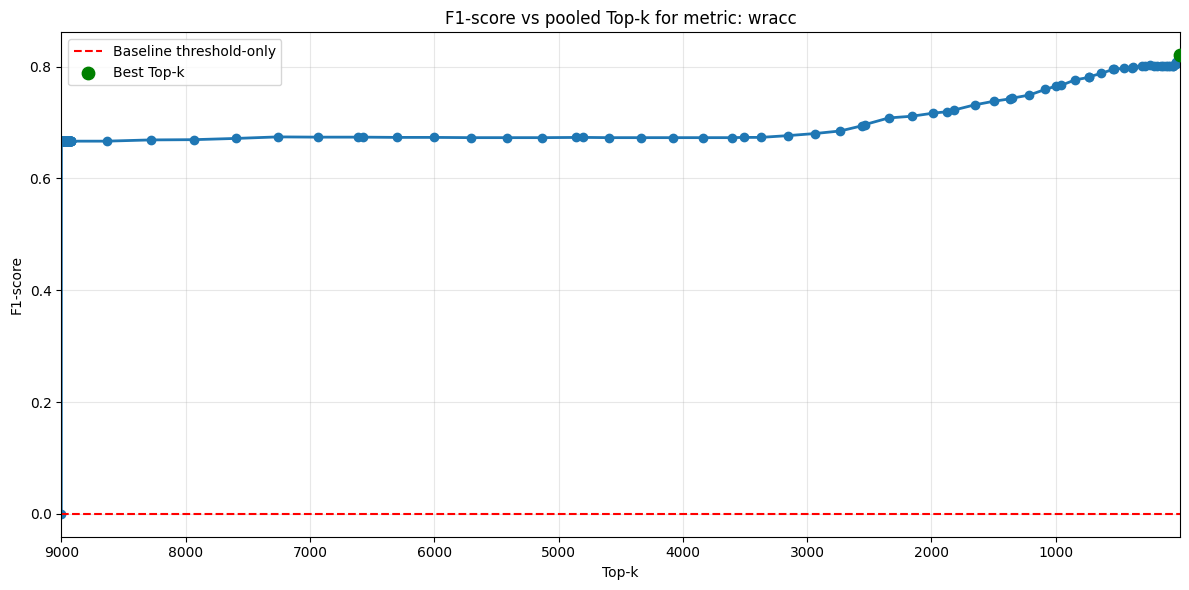

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\wracc_topk_f1.png
Best k for wracc: 2
Best F1-score: 0.820345
Average classifiers kept: 2.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,9000,0.000000,0.500,0.000000,0.0,0.500,9000.0
1,8999,0.666667,0.500,0.500000,1.0,0.500,8999.0
2,8998,0.666667,0.500,0.500000,1.0,0.500,8998.0
3,8997,0.666667,0.500,0.500000,1.0,0.500,8997.0
4,8996,0.666667,0.500,0.500000,1.0,0.500,8996.0
...,...,...,...,...,...,...,...
150,5,0.815661,0.774,0.688705,1.0,0.784,5.0
151,4,0.817661,0.777,0.691563,1.0,0.782,4.0
152,3,0.816327,0.775,0.689655,1.0,0.781,3.0
153,2,0.820345,0.781,0.695410,1.0,0.781,2.0


In [10]:
wracc_results = plot_metric_topk("wracc", k_values)
wracc_results

## Run Any Metric

Examples:
- `plot_metric_topk("precision", k_values)`
- `plot_metric_topk("balanced_precision_proxy", k_values)`
- `plot_metric_topk("information_gain", k_values)`
- `plot_metric_topk("query_weighted_precision", k_values)`
- `plot_metric_topk("stability", k_values)`

Caching information_gain:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating information_gain:   0%|          | 0/155 [00:00<?, ?it/s]

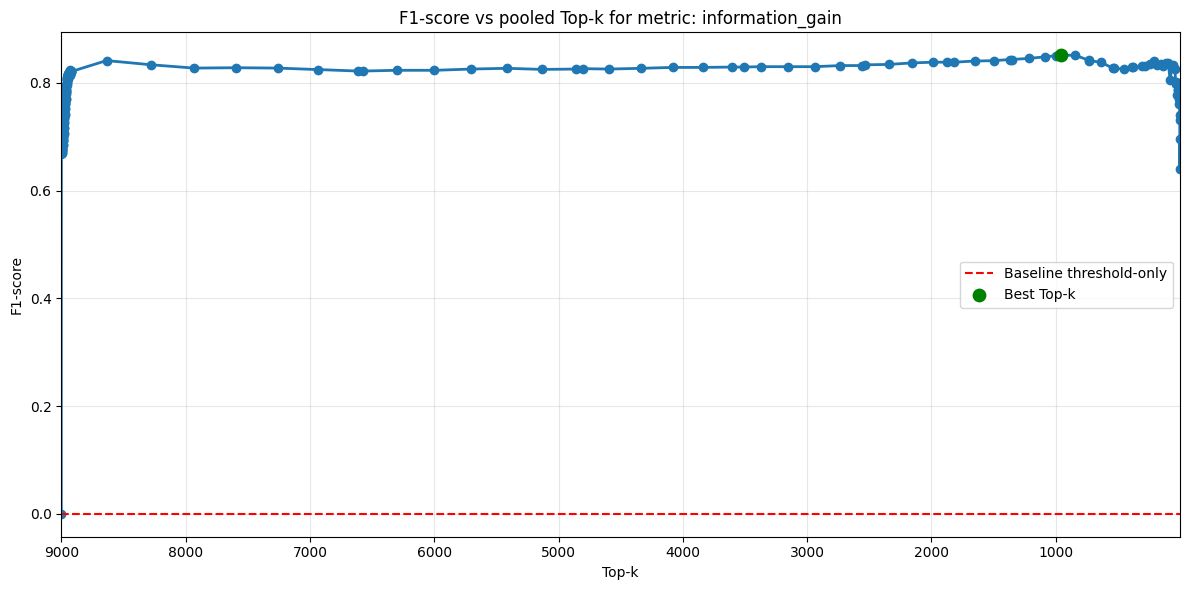

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\information_gain_topk_f1.png
Best k for information_gain: 960
Best F1-score: 0.851064
Average classifiers kept: 960.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,9000,0.000000,0.500,0.000000,0.000,0.500000,9000.0
1,8999,0.668003,0.503,0.501505,1.000,0.503000,8999.0
2,8998,0.669344,0.506,0.503018,1.000,0.506000,8998.0
3,8997,0.669344,0.506,0.503018,1.000,0.518000,8997.0
4,8996,0.674309,0.517,0.508647,1.000,0.524000,8996.0
...,...,...,...,...,...,...,...
150,5,0.800386,0.793,0.772812,0.830,0.811068,5.0
151,4,0.731452,0.743,0.765864,0.700,0.800758,4.0
152,3,0.739669,0.748,0.764957,0.716,0.791532,3.0
153,2,0.640094,0.693,0.773371,0.546,0.770466,2.0


In [11]:
metric_name = "information_gain"
results = plot_metric_topk(metric_name, k_values)
results

## Batch Run Over Several Metrics

This cell is optional. It can take time, but it is still much cheaper than recomputing explanations for every metric and every k.

In [12]:
metrics_to_try = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

summary_rows = []
for metric_name in metrics_to_try:
    results = evaluate_metric_topk(metric_name, k_values)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": best_row["F1-score"],
        "avg_classifiers_kept": best_row["Average classifiers kept"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df

Caching wracc:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/155 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/155 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/155 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/155 [00:00<?, ?it/s]

,metric,best_k,best_f1,avg_classifiers_kept
1,lift,844,0.900092,844.0
8,query_weighted_precision,81,0.898258,81.0
4,information_gain,960,0.851064,960.0
7,g_test,960,0.851064,960.0
5,gini_gain,8636,0.835570,8636.0
6,chi_squared,8636,0.835570,8636.0
3,matthews_correlation,2,0.825764,2.0
9,query_weighted_wracc,2,0.821018,2.0
0,wracc,2,0.820345,2.0
2,balanced_precision_proxy,2,0.820345,2.0



=== wracc ===


Caching wracc:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/155 [00:00<?, ?it/s]

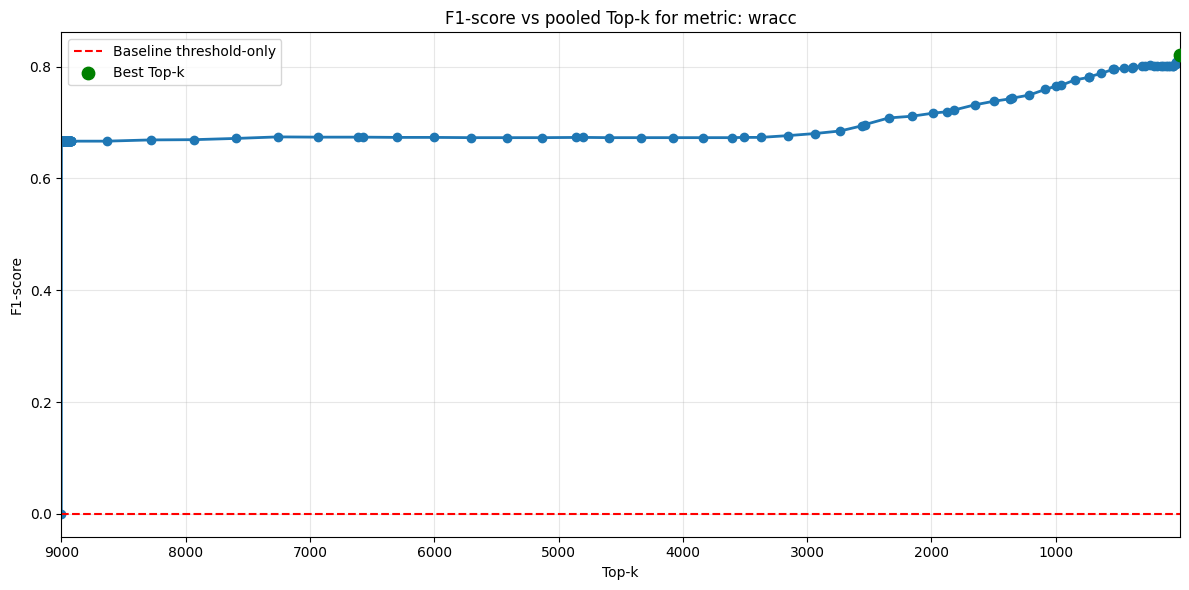

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\wracc_topk_f1.png
Best k for wracc: 2
Best F1-score: 0.820345
Average classifiers kept: 2.00

=== lift ===


Caching lift:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/155 [00:00<?, ?it/s]

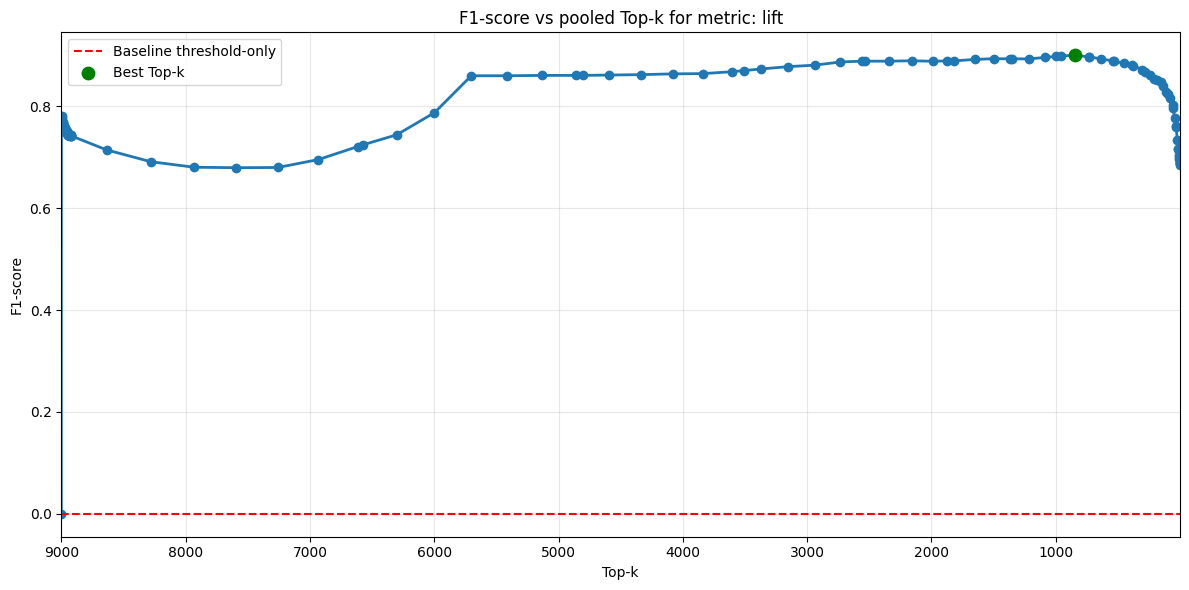

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\lift_topk_f1.png
Best k for lift: 844
Best F1-score: 0.900092
Average classifiers kept: 844.00

=== balanced_precision_proxy ===


Caching balanced_precision_proxy:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating balanced_precision_proxy:   0%|          | 0/155 [00:00<?, ?it/s]

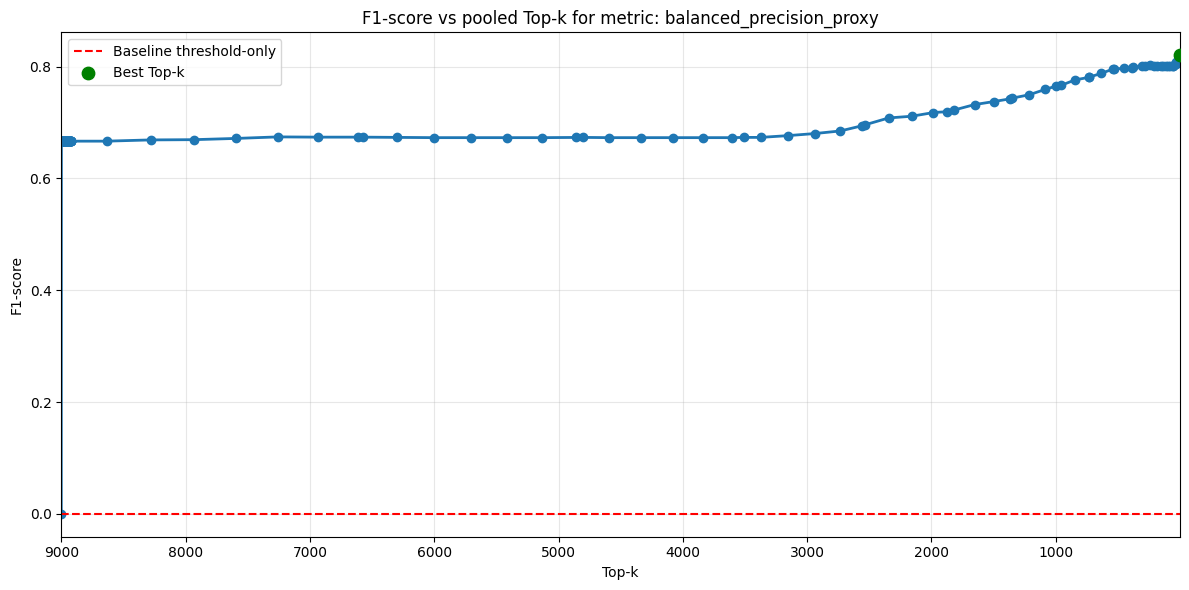

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\balanced_precision_proxy_topk_f1.png
Best k for balanced_precision_proxy: 2
Best F1-score: 0.820345
Average classifiers kept: 2.00

=== youdens_j ===


Caching youdens_j:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating youdens_j:   0%|          | 0/155 [00:00<?, ?it/s]

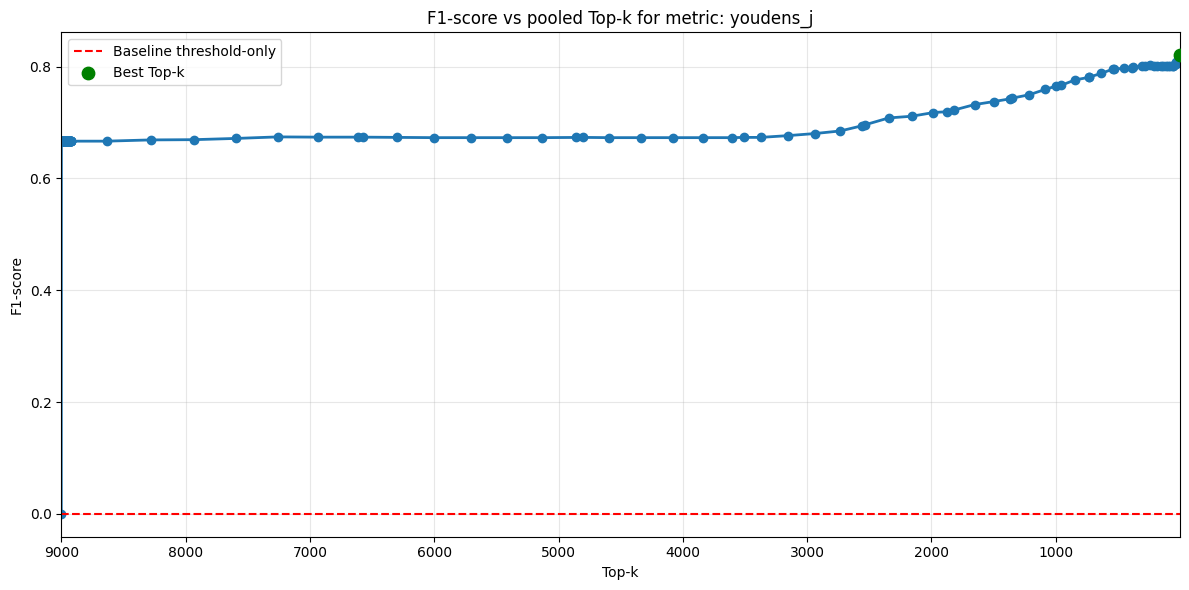

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\youdens_j_topk_f1.png
Best k for youdens_j: 2
Best F1-score: 0.820345
Average classifiers kept: 2.00

=== matthews_correlation ===


Caching matthews_correlation:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating matthews_correlation:   0%|          | 0/155 [00:00<?, ?it/s]

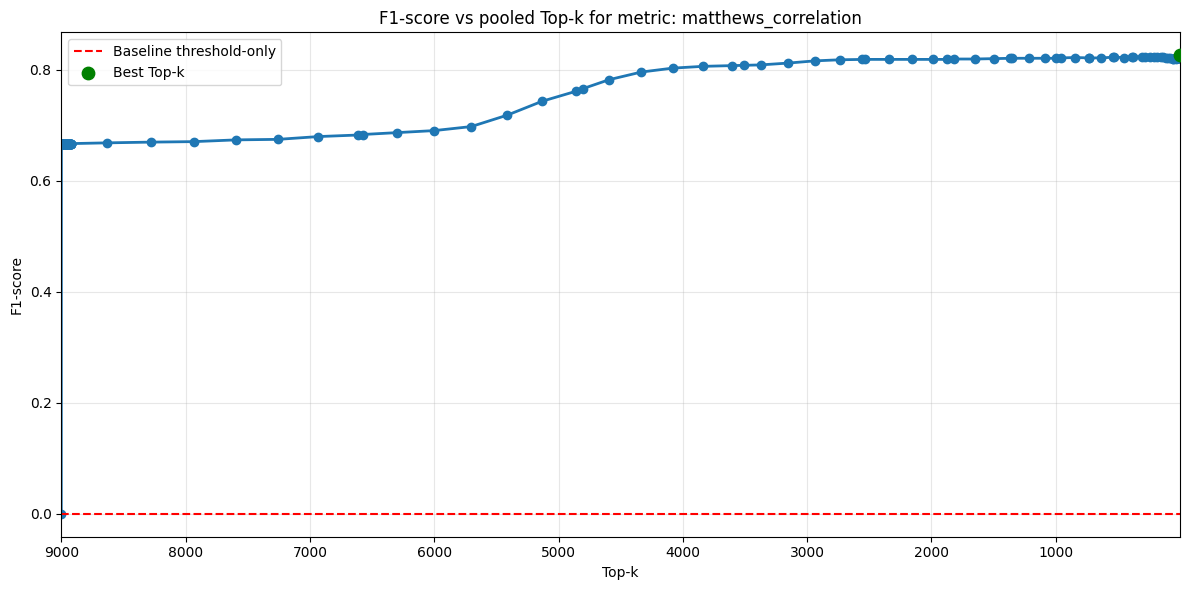

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\matthews_correlation_topk_f1.png
Best k for matthews_correlation: 2
Best F1-score: 0.825764
Average classifiers kept: 2.00

=== information_gain ===


Caching information_gain:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating information_gain:   0%|          | 0/155 [00:00<?, ?it/s]

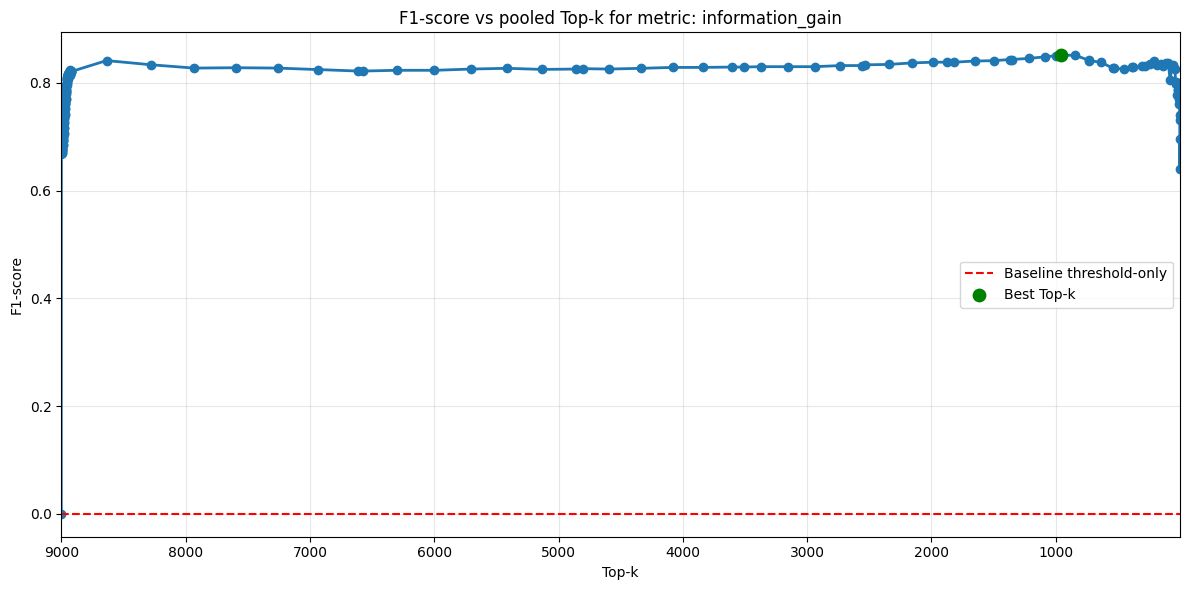

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\information_gain_topk_f1.png
Best k for information_gain: 960
Best F1-score: 0.851064
Average classifiers kept: 960.00

=== gini_gain ===


Caching gini_gain:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating gini_gain:   0%|          | 0/155 [00:00<?, ?it/s]

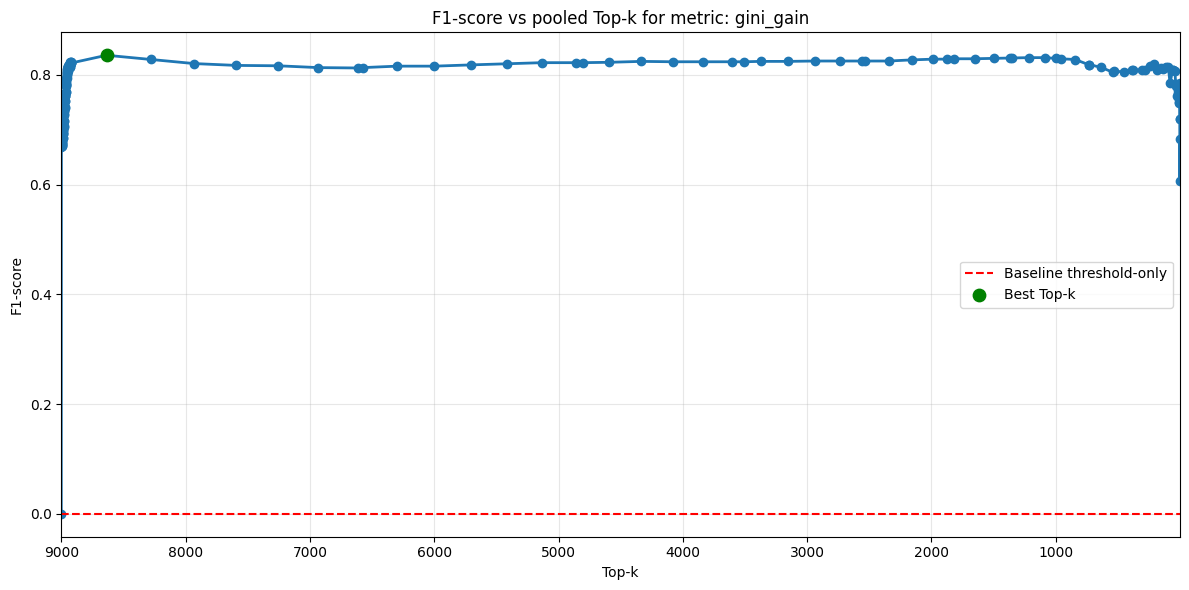

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\gini_gain_topk_f1.png
Best k for gini_gain: 8636
Best F1-score: 0.835570
Average classifiers kept: 8636.00

=== log_odds_ratio ===


Caching log_odds_ratio:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating log_odds_ratio:   0%|          | 0/155 [00:00<?, ?it/s]

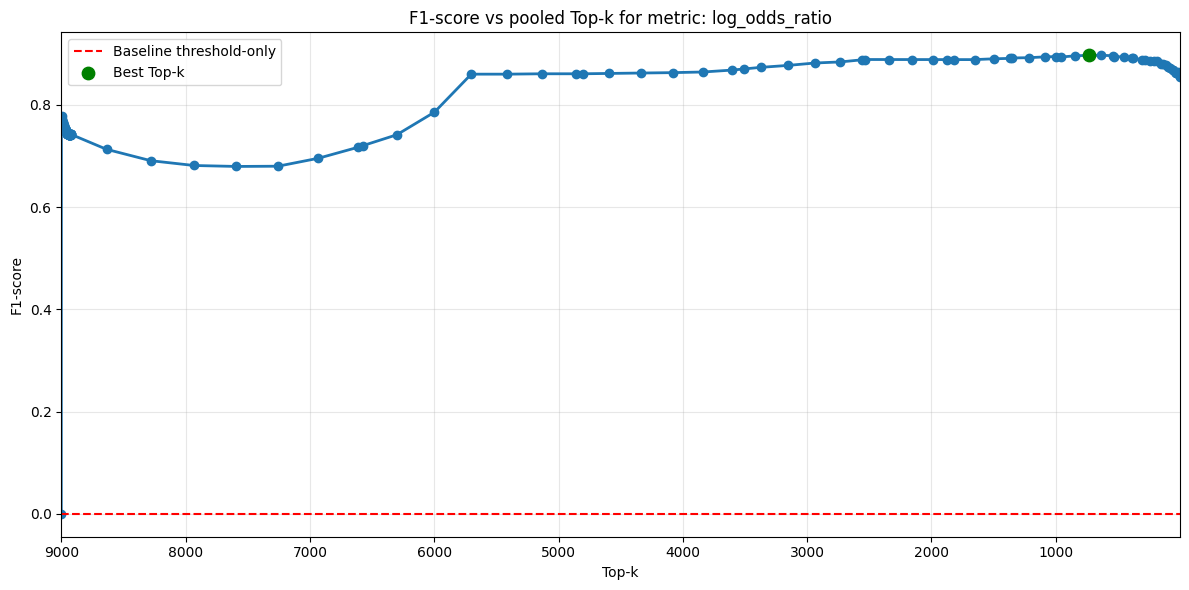

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\log_odds_ratio_topk_f1.png
Best k for log_odds_ratio: 736
Best F1-score: 0.896804
Average classifiers kept: 736.00

=== chi_squared ===


Caching chi_squared:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating chi_squared:   0%|          | 0/155 [00:00<?, ?it/s]

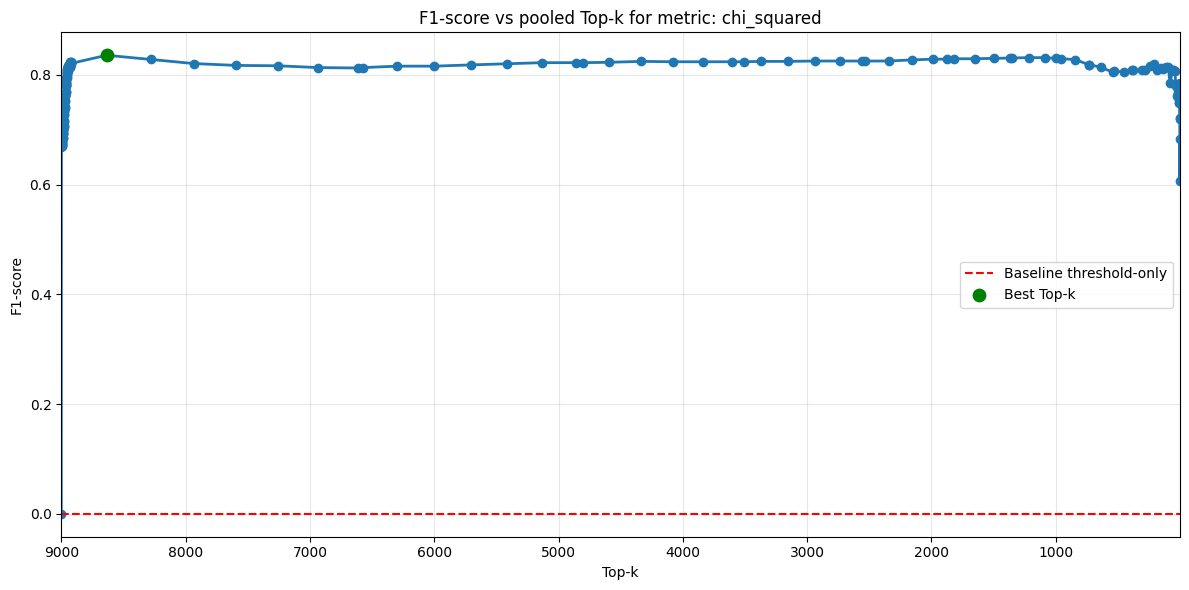

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\chi_squared_topk_f1.png
Best k for chi_squared: 8636
Best F1-score: 0.835570
Average classifiers kept: 8636.00

=== g_test ===


Caching g_test:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating g_test:   0%|          | 0/155 [00:00<?, ?it/s]

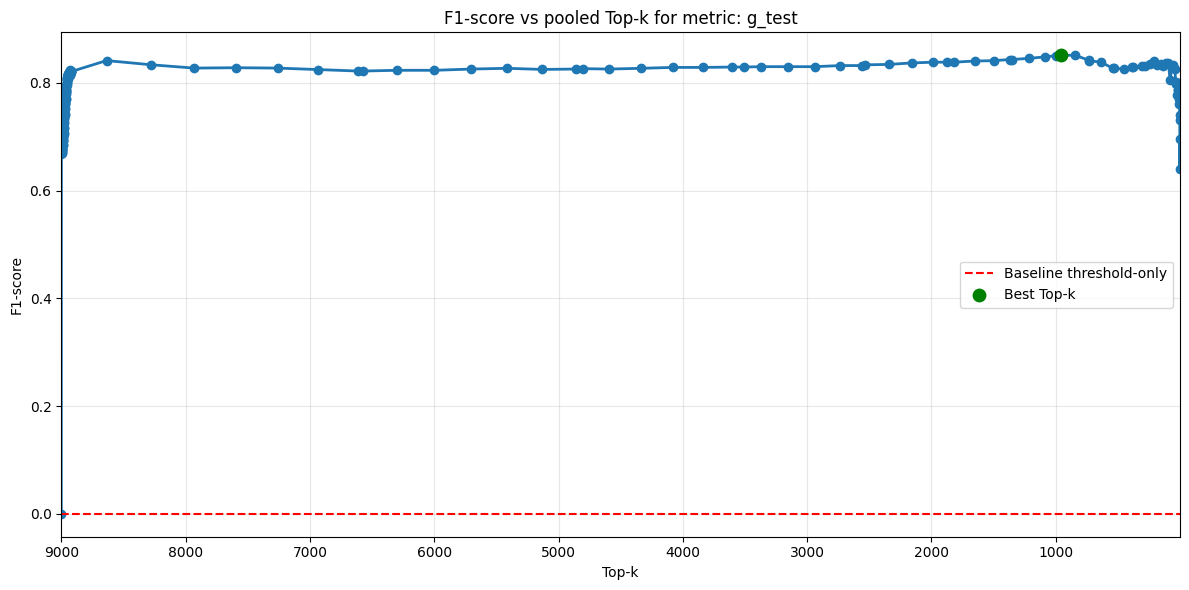

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\g_test_topk_f1.png
Best k for g_test: 960
Best F1-score: 0.851064
Average classifiers kept: 960.00

=== query_weighted_precision ===


Caching query_weighted_precision:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating query_weighted_precision:   0%|          | 0/155 [00:00<?, ?it/s]

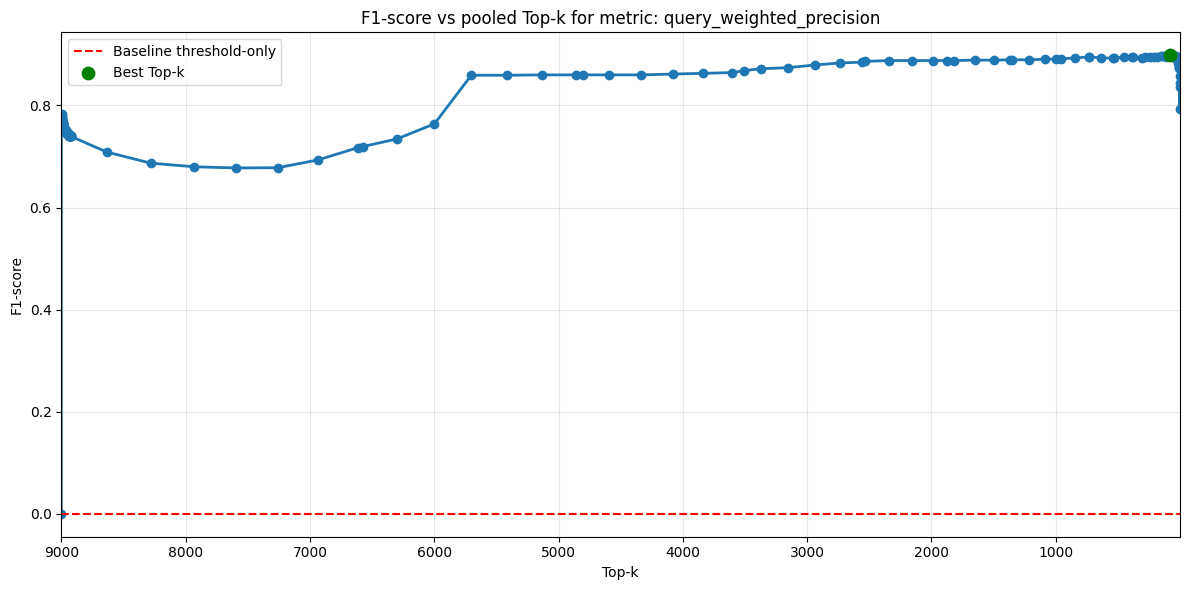

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\query_weighted_precision_topk_f1.png
Best k for query_weighted_precision: 81
Best F1-score: 0.898258
Average classifiers kept: 81.00

=== query_weighted_wracc ===


Caching query_weighted_wracc:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating query_weighted_wracc:   0%|          | 0/155 [00:00<?, ?it/s]

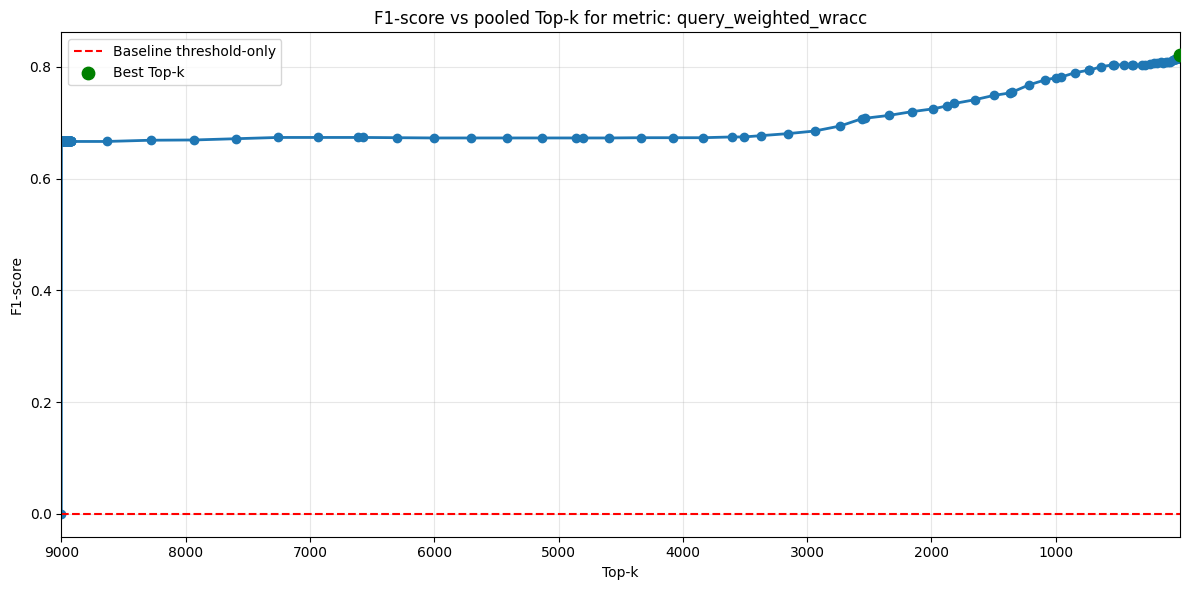

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\query_weighted_wracc_topk_f1.png
Best k for query_weighted_wracc: 2
Best F1-score: 0.821018
Average classifiers kept: 2.00

=== stability ===


Caching stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/155 [00:00<?, ?it/s]

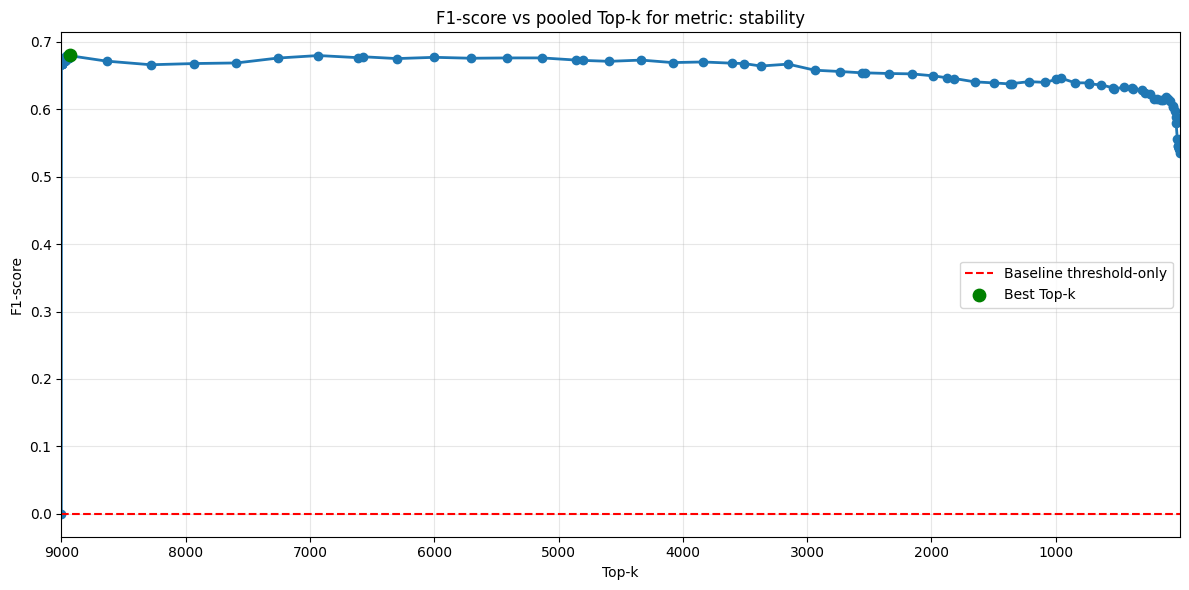

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\stability_topk_f1.png
Best k for stability: 8930
Best F1-score: 0.680300
Average classifiers kept: 8930.00

=== delta_stability ===


Caching delta_stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/155 [00:00<?, ?it/s]

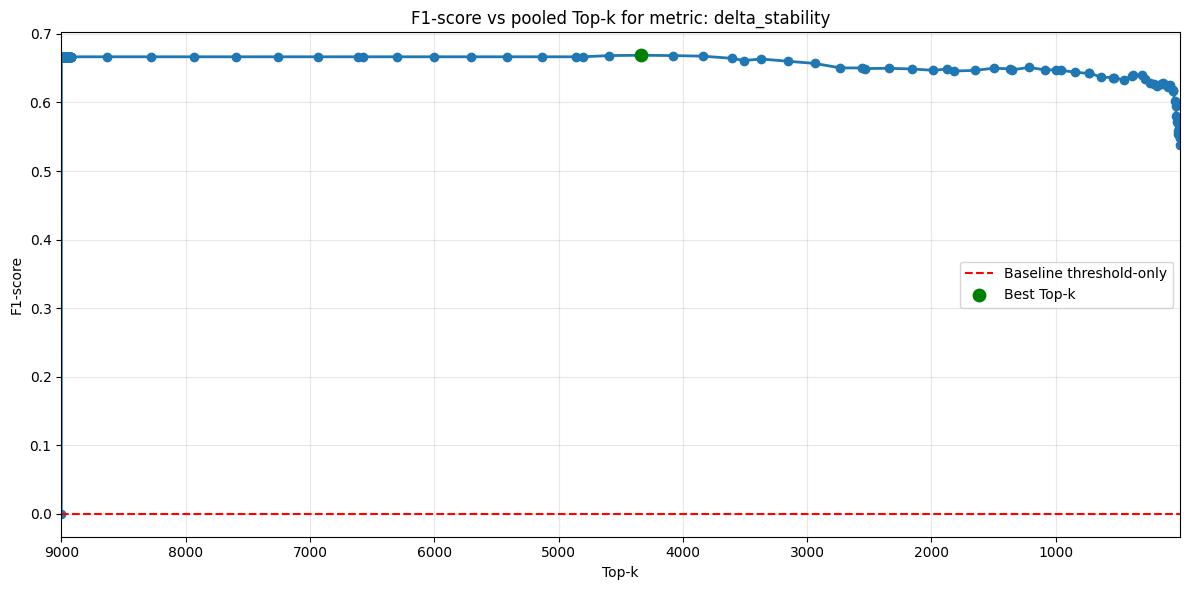

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\delta_stability_topk_f1.png
Best k for delta_stability: 4334
Best F1-score: 0.668901
Average classifiers kept: 4334.00


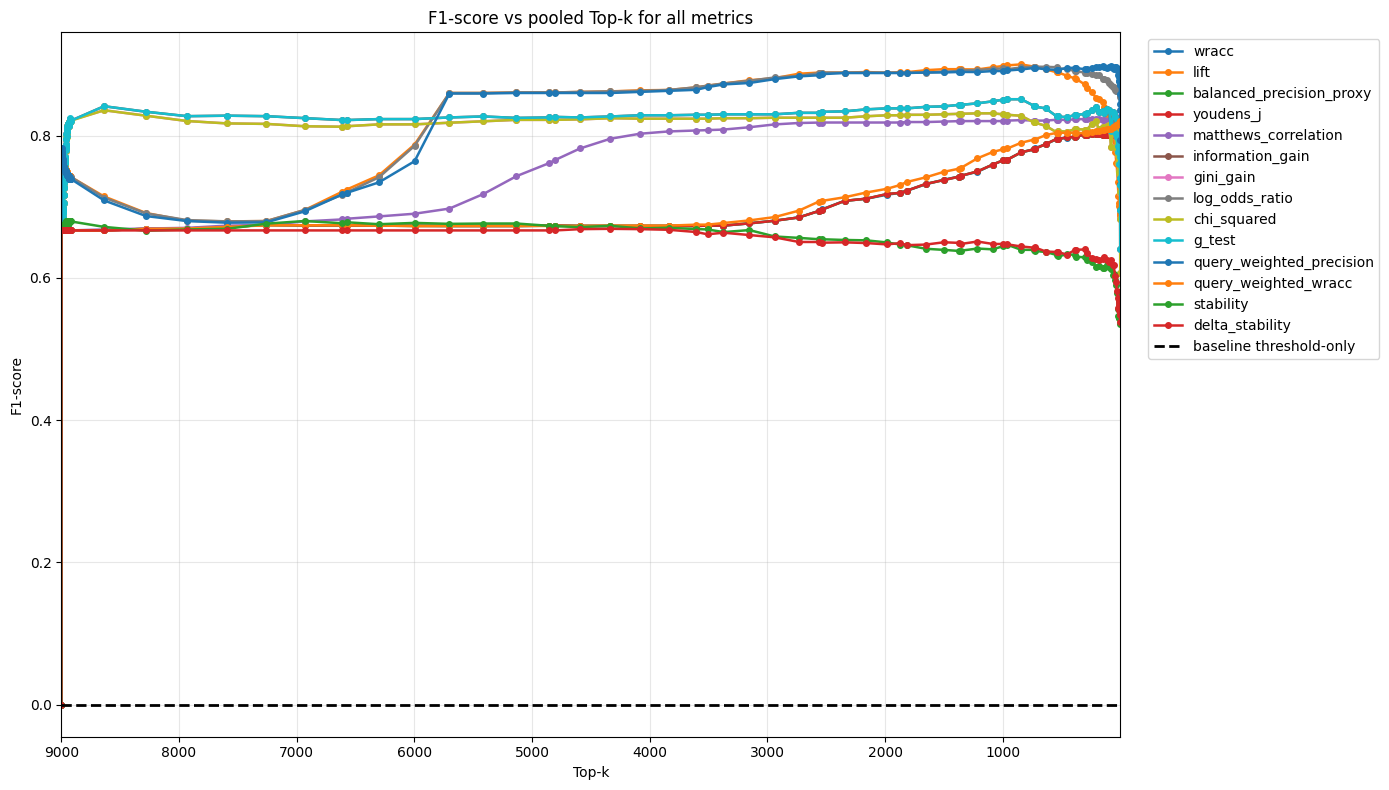


Saved combined plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\all_metrics_topk_f1.png
Saved summary CSV to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\topk_summary.csv


,metric,best_k,best_f1,avg_classifiers_kept
1,lift,844,0.900092,844.0
10,query_weighted_precision,81,0.898258,81.0
7,log_odds_ratio,736,0.896804,736.0
5,information_gain,960,0.851064,960.0
9,g_test,960,0.851064,960.0
6,gini_gain,8636,0.835570,8636.0
8,chi_squared,8636,0.835570,8636.0
4,matthews_correlation,2,0.825764,2.0
11,query_weighted_wracc,2,0.821018,2.0
0,wracc,2,0.820345,2.0


In [13]:
metrics_to_plot = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

all_results = {}
summary_rows = []

for metric_name in metrics_to_plot:
    print(f"\n=== {metric_name} ===")
    results = plot_metric_topk(metric_name, k_values)
    all_results[metric_name] = results.copy()

    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]

    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": float(best_row["F1-score"]),
        "avg_classifiers_kept": float(best_row["Average classifiers kept"]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df.to_csv(PLOTS_DIR / "topk_summary.csv", index=False)

# Combined plot with all metrics together
plt.figure(figsize=(14, 8))
for metric_name, results in all_results.items():
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=1.8, markersize=4, label=metric_name)

plt.axhline(
    baseline_metrics["F1-score"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="baseline threshold-only"
)

plt.xlabel("Top-k")
plt.ylabel("F1-score")
plt.title("F1-score vs pooled Top-k for all metrics")
plt.xlim(max(k_values), min(k_values))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

combined_plot_path = PLOTS_DIR / "all_metrics_topk_f1.png"
plt.savefig(combined_plot_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"\nSaved combined plot to: {combined_plot_path}")
print(f"Saved summary CSV to: {PLOTS_DIR / 'topk_summary.csv'}")

summary_df


In [14]:
metric_name = "query_weighted_precision"
k_value = 20

results = evaluate_metric_topk(metric_name, np.array([k_value]))
row = results.iloc[0]

print(f"Metric: {metric_name}")
print(f"Top-k: {int(row['k'])}")
print(f"F1-score: {row['F1-score']:.6f}")
print(f"Accuracy: {row['Accuracy']:.6f}")
print(f"Precision: {row['Precision']:.6f}")
print(f"Recall: {row['Recall']:.6f}")
print(f"AUC-ROC: {row['AUC-ROC']:.6f}")
print(f"Average classifiers kept: {row['Average classifiers kept']:.2f}")


Caching query_weighted_precision:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating query_weighted_precision:   0%|          | 0/1 [00:00<?, ?it/s]

Metric: query_weighted_precision
Top-k: 20
F1-score: 0.887661
Accuracy: 0.878000
Precision: 0.822526
Recall: 0.964000
AUC-ROC: 0.912670
Average classifiers kept: 20.00


In [15]:
def rank_metrics_by_f1_retention(
    metrics_to_check,
    allowed_drop_percent=5.0,
    k_values=k_values,
    baseline_f1=None,
    explanations=explanations,
    y_true=y_test,
    pos_weight=1.0,
):
    """
    Rank metrics by how aggressively they can prune while keeping F1 within
    an allowed percentage drop from baseline.

    Rule:
    - Let baseline F1 be F_base.
    - Allowed minimum F1 is:
          F_min = F_base * (1 - allowed_drop_percent / 100)
    - We scan k_values in descending order (from large k to small k).
    - As soon as F1 drops below F_min, we stop.
    - The selected k is the last valid k before the break.

    Output:
    - A dataframe ordered best -> worst.
    - Best means smaller retained k first.
    - Ties are broken by higher retained F1.
    """

    if baseline_f1 is None:
        baseline_f1 = float(baseline_metrics["F1-score"])

    if allowed_drop_percent < 0:
        raise ValueError("allowed_drop_percent must be non-negative")

    f1_threshold = baseline_f1 * (1.0 - allowed_drop_percent / 100.0)

    rows = []

    for metric_name in metrics_to_check:
        results = evaluate_metric_topk(
            metric_name=metric_name,
            k_values=k_values,
            explanations=explanations,
            y_true=y_true,
            pos_weight=pos_weight,
        ).sort_values("k", ascending=False).reset_index(drop=True)

        last_valid_row = None
        broke = False

        for _, row in results.iterrows():
            if row["F1-score"] >= f1_threshold:
                last_valid_row = row
            else:
                broke = True
                break

        if last_valid_row is None:
            rows.append({
                "metric": metric_name,
                "selected_k": np.nan,
                "selected_f1": np.nan,
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": np.nan,
                "status": "never_satisfies_rule",
            })
        else:
            rows.append({
                "metric": metric_name,
                "selected_k": int(last_valid_row["k"]),
                "selected_f1": float(last_valid_row["F1-score"]),
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": float(last_valid_row["Average classifiers kept"]),
                "status": "break_found" if broke else "all_k_valid",
            })

    summary = pd.DataFrame(rows)

    # Best -> worst:
    # 1) metrics that satisfy the rule
    # 2) among them, smaller selected_k is better
    # 3) if tied, higher F1 is better
    # 4) metrics that never satisfy the rule go last
    summary["valid"] = summary["selected_k"].notna()

    summary = summary.sort_values(
        by=["valid", "selected_k", "selected_f1"],
        ascending=[False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    return summary.drop(columns=["valid"])


In [16]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=5.0,
)


Caching wracc:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/155 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/155 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/155 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/155 [00:00<?, ?it/s]

,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,log_odds_ratio,1,0.857143,0.0,0.0,1.0,all_k_valid
1,query_weighted_precision,1,0.836000,0.0,0.0,1.0,all_k_valid
2,matthews_correlation,1,0.825764,0.0,0.0,1.0,all_k_valid
3,query_weighted_wracc,1,0.819672,0.0,0.0,1.0,all_k_valid
4,wracc,1,0.819001,0.0,0.0,1.0,all_k_valid
5,balanced_precision_proxy,1,0.819001,0.0,0.0,1.0,all_k_valid
6,youdens_j,1,0.819001,0.0,0.0,1.0,all_k_valid
7,information_gain,1,0.694933,0.0,0.0,1.0,all_k_valid
8,g_test,1,0.694933,0.0,0.0,1.0,all_k_valid
9,lift,1,0.684621,0.0,0.0,1.0,all_k_valid


In [17]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=1.0,
)


Caching wracc:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/155 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/155 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/155 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/155 [00:00<?, ?it/s]

,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,log_odds_ratio,1,0.857143,0.0,0.0,1.0,all_k_valid
1,query_weighted_precision,1,0.836000,0.0,0.0,1.0,all_k_valid
2,matthews_correlation,1,0.825764,0.0,0.0,1.0,all_k_valid
3,query_weighted_wracc,1,0.819672,0.0,0.0,1.0,all_k_valid
4,wracc,1,0.819001,0.0,0.0,1.0,all_k_valid
5,balanced_precision_proxy,1,0.819001,0.0,0.0,1.0,all_k_valid
6,youdens_j,1,0.819001,0.0,0.0,1.0,all_k_valid
7,information_gain,1,0.694933,0.0,0.0,1.0,all_k_valid
8,g_test,1,0.694933,0.0,0.0,1.0,all_k_valid
9,lift,1,0.684621,0.0,0.0,1.0,all_k_valid
